## Baro Array - Coherence

### Importing

In [1]:
import os
import gc
import numpy as np
import matplotlib.pyplot as plt
import obspy
import pandas as pd

from obspy import Stream

from andbro__read_sds import __read_sds

from functions.interpolate_nan import __interpolate_nan

In [2]:
if os.uname().nodename == 'lighthouse':
    root_path = '/home/andbro/'
    data_path = '/home/andbro/kilauea-data/'
    archive_path = '/home/andbro/freenas/'
    bay_path = '/home/andbro/ontap-ffb-bay200/'
    lamont_path = '/home/andbro/lamont/'
elif os.uname().nodename == 'kilauea':
    root_path = '/home/brotzer/'
    data_path = '/import/kilauea-data/'
    archive_path = '/import/freenas-ffb-01-data/'
    bay_path = '/import/ontap-ffb-bay200/'
    lamont_path = '/lamont/'
elif os.uname().nodename in ['lin-ffb-01', 'ambrym', 'hochfelln']:
    root_path = '/home/brotzer/'
    data_path = '/import/kilauea-data/'
    archive_path = '/import/freenas-ffb-01-data/'
    bay_path = '/import/ontap-ffb-bay200/'
    lamont_path = '/lamont/'

### Setting Variables

In [209]:
config = {}

# config['klim'] = 50.
# config['kstep'] = config['klim'] / 100.

# example 1
# config['tbeg'] = obspy.UTCDateTime("2024-03-16 06:00")
# config['tend'] = obspy.UTCDateTime("2024-03-16 18:00")

# example 2
# config['tbeg'] = obspy.UTCDateTime("2024-03-23 06:00")
# config['tend'] = obspy.UTCDateTime("2024-03-23 17:00")

# example 3
# config['tbeg'] = obspy.UTCDateTime("2024-03-23 00:00")
# config['tend'] = obspy.UTCDateTime("2024-03-25 00:00")

# example 4
config['tbeg'] = obspy.UTCDateTime("2024-08-29 15:00")
config['tend'] = obspy.UTCDateTime("2024-08-29 17:00")

# config['tbeg'] = obspy.UTCDateTime("2024-09-08 00:00")
# config['tend'] = obspy.UTCDateTime("2024-09-09 00:00")


config['seeds'] = [
                   'BW.PROMY.04.LDI',
                   'BW.GELB..LDO',
                   'BW.GRMB..LDO',
                   'BW.ALFT..LDO',
                   'BW.BIB..LDO',
                   'BW.TON..LDO',
]

config['fmin'] = 5e-4
config['fmax'] = 10e-3

config['path_to_figs'] = data_path+"/romy_baro/figures/"


config['coos'] = { "ALFT":{"lon":11.2795 , "lat":48.142334, "height":593.0},
                   "GELB":{"lon":11.2514 , "lat":48.1629, "height":628.0},
                   "GRMB":{"lon":11.2635 , "lat":48.1406, "height":656.0},
                   "TON":{"lon":11.288809 , "lat":48.173897, "height":564.0},
                   "BIB":{"lon":11.2473 , "lat":48.1522, "height":599.0},
                   "PROMY":{"lon":11.275501 , "lat":48.162941, "height":571.0},
                  }

In [314]:
class baroArray:

    def __init__(self, seeds=[], coords=None,
                 path_to_figs="./", verbose=False,
                 fmin=None, fmax=None, out_seed="BW.BRMY..BDX"):

        # specify station codes
        self.seeds = seeds

        # station coordinates
        self.coordinates = coords

        # path to output figures
        self.path_to_figs = path_to_figs

        self.verbose = verbose

        self.fmin = fmin

        self.fmax = fmax

        self.apply_bandpass = True

        self.plot = False

        self.out_seed = out_seed

        self.aperture = None

        # adr parameters
        self.vp = 1
        self.vs = 1
        self.sigmau = 1e-7

    def load_data(self, tbeg, tend, path_to_sds, verbose=False):

        from obspy import UTCDateTime, Stream
        from numpy import isnan

        # starttime and endtime
        self.tbeg = UTCDateTime(tbeg)
        self.tend = UTCDateTime(tend)

        # specify path to data
        self.path_to_sds = path_to_sds

        # establish data stream
        self.st0 = Stream()

        for _i, seed in enumerate(self.seeds):

            # if "ROMY" in seed:
            #     seed = "BW.PROMY.03.LDI"

            ps = self.read_sds(self.path_to_sds, seed, self.tbeg, self.tend)

            for tr in ps:
                if isnan(tr.data).any():
                    if self.verbose or verbose:
                        print("-> NaN found! Interpolating NaNs ...")
                    tr.data = self.interpolate_nan(tr.data)

            try:

                # convert from Pa to hPa
                if "PROMY.03" in seed:
                    ps[0].data = ps[0].data / 100

#                 ps = ps.detrend("simple")

#                 ps = ps.taper(0.01, type="cosine")

#                 ps = ps.filter("bandpass", freqmin=self.fmin, freqmax=self.fmax, corners=4, zerophase=True)

#                 ps = ps.resample(self.fmax*10, no_filter=True)

                # convert from hPa to Pa
                ps[0].data = ps[0].data * 100

                if self.verbose or verbose:
                    print(ps)

                self.st0 += ps

                del ps

            except:
                print(f" -> Error encountered for {seed}")

    def preprocessing(self, fmin, fmax, resample=False):

        self.fmin = fmin
        self.fmax = fmax

        self.st = self.st0.copy()

        self.st.detrend("simple")

        self.st.taper(0.01, type="cosine")

        self.st.filter("bandpass", freqmin=self.fmin, freqmax=self.fmax, corners=4, zerophase=True)

        if resample:
            self.st.resample(self.fmax*10, no_filter=True)

    def compute_gradient(self, reference, fmin=None, fmax=None, verbose=False):

        import matplotlib.pyplot as plt

        from obspy import Stream
        from obspy.signal.util import util_geo_km
        from numpy import array

        # assign reference
        self.reference = reference

        # get data stream
        st = self.st.copy()

        # change channel name
        for tr in st:
            tr.stats.channel = "LDZ"

        # add placebo N component
        _stN = st.copy()
        for tr in _stN:
            tr.stats.channel = "LDN"

        # add placebo E component
        _stE = st.copy()
        for tr in _stE:
            tr.stats.channel = "LDE"

        st += _stN.copy()
        st += _stE.copy()

        # processing
        st = st.detrend("linear")
        st = st.detrend("demean")

        # bandpass filter
        if self.apply_bandpass:
            st = st.taper(0.02, type="cosine")
            if fmin is None and fmax is None:
                fmin, fmax = self.fmin, self.fmax
                st = st.filter('bandpass', freqmin=self.fmin, freqmax=self.fmax, corners=4, zerophase=True)
            else:
                st = st.filter('bandpass', freqmin=fmin, freqmax=fmax, corners=4, zerophase=True)
            if verbose:
                print(f" -> applying bandpass: {fmin} - {fmax} Hz")

        # compute relataive distances
        dist = []
        for k in self.coordinates.keys():

            coo = self.coordinates[k]

            ref_sta = self.reference.split(".")[1]

            # reference
            coo_ref = self.coordinates[ref_sta]
            ref_lon, ref_lat, ref_height = coo_ref['lon'], coo_ref['lat'], coo_ref['height']

            # convert
            lon, lat = util_geo_km(ref_lon, ref_lat, coo['lon'], coo['lat'])

            # convert unit from km to m
            dist.append([lon*1000, lat*1000, coo['height']-ref_height])

        # assign distances
        self.distances = array(dist)

        # check if enough stations for ADR are available otherwise continue
        if len(st) < 3*3:
            print(" -> not enough stations (< 3) for ADR computation!")
            return
        else:
            if verbose:
                print(f" -> continue computing ADR for {int(len(st)/3)} of {len(self.seeds)} stations ...")

        # homogenize the time line
        # st = __adjust_time_line(st, reference=config['reference_station'])

        # check for same amount of samples
        self.check_samples_in_stream()

        # compute array derived rotation (ADR)
        try:
            self.compute_adr(st)
        except Exception as e:
            print(f"failed")
            self.gradient = Stream()
            if verbose:
                print(e)

        # trim to requested interval
        self.gradient.trim(self.tbeg, self.tend)

        # remove Z trace (not possible to compute for pressure)
        for tr in self.gradient:
            if "Z" in tr.stats.channel:
                self.gradient.remove(tr);

    def compute_adr(self, st):

        from obspy.signal import array_analysis as AA
        from obspy import Stream
        from numpy import array, arange, transpose

        # reference stream
        sta = self.reference.split(".")[1]
        ref_st = st.select(station=sta)[0]

        # prepare data arrays
        tsz, tsn, tse = [], [], []
        for tr in st:
            try:
                if "Z" in tr.stats.channel:
                    tsz.append(tr.data)
                elif "N" in tr.stats.channel:
                    tsn.append(tr.data)
                elif "E" in tr.stats.channel:
                    tse.append(tr.data)
            except:
                if self.verbose:
                    print(" -> stream data could not be appended!")

        # make sure input is array type
        tse, tsn, tsz = array(tse), array(tsn), array(tsz)

        # define array for subarray stations with linear numbering
        substations = arange(len(self.seeds))

        try:
            result = AA.array_rotation_strain(substations,
                                              transpose(tse),
                                              transpose(tsn),
                                              transpose(tsz),
                                              self.vp,
                                              self.vs,
                                              self.distances,
                                              self.sigmau,
                                             )
        except Exception as e:
            if self.verbose:
                print(e)
                print("\n -> failed to compute ADR...")
                self.gradient = Stream()
                return

        # create rotation stream and add data
        out = Stream()
        out += ref_st.copy()
        out += ref_st.copy()
        out += ref_st.copy()

        out[0].data = result['ts_w3']
        out[1].data = result['ts_w2']
        out[2].data = result['ts_w1']

        out[0].stats.network = self.out_seed.split(".")[0]
        out[1].stats.network = self.out_seed.split(".")[0]
        out[2].stats.network = self.out_seed.split(".")[0]

        out[0].stats.station = self.out_seed.split(".")[1]
        out[1].stats.station = self.out_seed.split(".")[1]
        out[2].stats.station = self.out_seed.split(".")[1]

        out[0].stats.location = self.out_seed.split(".")[2]
        out[1].stats.location = self.out_seed.split(".")[2]
        out[2].stats.location = self.out_seed.split(".")[2]

        out[0].stats.channel = 'BDZ'
        out[1].stats.channel = 'BDN'
        out[2].stats.channel = 'BDE'

        out = out.detrend('linear')

        self.gradient = out

    def check_samples_in_stream(self):

        Rnet, Rsta = self.reference.split(".")

        Rsamples = self.st.select(network=Rnet, station=Rsta)[0].stats.npts

        for tr in self.st:
            if tr.stats.npts != Rsamples:
                print(f" -> removing {tr.stats.station} due to improper number of samples ({tr.stats.npts} not {Rsamples})")
                self.st.remove(tr)

    def write_stream_to_sds(self, path_to_dir=None, verbose=False):

        if path_to_dir is None:
            path_to_sds = self.path_to_sds
        else:
            path_to_sds = path_to_dir
        import os

        # check if output path exists
        if not os.path.exists(path_to_sds):
            print(f" -> {path_to_sds} does not exist!")
            return

        for tr in self.gradient:
            nn, ss, ll, cc = tr.stats.network, tr.stats.station, tr.stats.location, tr.stats.channel
            yy, jj = tr.stats.starttime.year, tr.stats.starttime.julday

            if not os.path.exists(path_to_sds+f"{yy}/"):
                os.mkdir(path_to_sds+f"{yy}/")
                print(f"creating: {path_to_sds}{yy}/")
            if not os.path.exists(path_to_sds+f"{yy}/{nn}/"):
                os.mkdir(path_to_sds+f"{yy}/{nn}/")
                print(f"creating: {path_to_sds}{yy}/{nn}/")
            if not os.path.exists(path_to_sds+f"{yy}/{nn}/{ss}/"):
                os.mkdir(path_to_sds+f"{yy}/{nn}/{ss}/")
                print(f"creating: {path_to_sds}{yy}/{nn}/{ss}/")
            if not os.path.exists(path_to_sds+f"{yy}/{nn}/{ss}/{cc}.D"):
                os.mkdir(path_to_sds+f"{yy}/{nn}/{ss}/{cc}.D")
                print(f"creating: {path_to_sds}{yy}/{nn}/{ss}/{cc}.D")

        for tr in self.gradient:
            nn, ss, ll, cc = tr.stats.network, tr.stats.station, tr.stats.location, tr.stats.channel
            yy, jj = tr.stats.starttime.year, str(tr.stats.starttime.julday).rjust(3,"0")

            try:
                st_tmp = self.gradient.copy()
                st_tmp.select(network=nn, station=ss, location=ll, channel=cc).write(path_to_sds+f"{yy}/{nn}/{ss}/{cc}.D/"+f"{nn}.{ss}.{ll}.{cc}.D.{yy}.{jj}", format="MSEED")
            except:
                if self.verbose or verbose:
                    print(f" -> failed to write: {cc}")
            finally:
                if self.verbose or verbose:
                    print(f" -> stored stream as: {yy}/{nn}/{ss}/{cc}.D/{nn}.{ss}.{ll}.{cc}.D.{yy}.{jj}")

    def get_absolute_gradient(self):

        from numpy import sqrt

        E = self.gradient.select(channel="*E")[0].data
        N = self.gradient.select(channel="*N")[0].data

        self.abs_gradient = sqrt(N**2 + E**2)

    def get_angle(self, outunit="deg", relative_to_north=True):

        import numpy as np

        E = self.gradient.select(channel="*E")[0].data
        N = self.gradient.select(channel="*N")[0].data

        ang = np.zeros(len(E))

        for i, (n, e) in enumerate(zip(N, E)):
            # Q2
            if n >= 0 and e < 0:
                ang[i] = np.rad2deg(np.arctan(n/e)) + 180
            # Q3
            elif n < 0 and e < 0:
                ang[i] = np.rad2deg(np.arctan(n/e)) + 180
            # Q4
            elif n < 0 and e >= 0:
                ang[i] = np.rad2deg(np.arctan(n/e)) + 360
            # Q1
            else:
                ang[i] = np.rad2deg(np.arctan(n/e))

        # angle relative to north
        if relative_to_north:
            ang = ((ang + 90) % 360) - 180

        if outunit == "deg":
            self.angles = ang
        elif outunit == "rad":
            self.angles = np.deg2rad(ang)

    def makeplot(self, plot=False):

        import matplotlib.pyplot as plt
        import numpy as np
        from matplotlib.gridspec import GridSpec

        t = self.gradient.select(channel="*N")[0].times()
        N = self.gradient.select(channel="*N")[0].data
        E = self.gradient.select(channel="*E")[0].data

        # pressure data
        tt = self.st.select(station="PROMY")[0].times()
        pp = self.st.select(station="PROMY")[0].data

        # get angles
        self.get_angle()
        brmy_ang = self.angles

        # get absolute gradient
        self.get_absolute_gradient()
        brmy_abs = self.abs_gradient

        # normalized absolute gradient
        r = brmy_abs / max(brmy_abs)

        # specify limit for r
        rlim = 0.2

        # angle as radians
        theta = np.deg2rad(brmy_ang)

        # ___________________________________________

        tscale, tunit = 1/3600, "hour"

        gscale, gunit = 1e6, ""

        Ncol, Nrow = 9, 4

        font = 12

        fig = plt.figure(figsize=(15, 5))

        gs1 = GridSpec(Nrow, Ncol, figure=fig, hspace=0.1, wspace=0.2)

        ax0 = fig.add_subplot(gs1[0, :5])
        ax1 = fig.add_subplot(gs1[1, :5])
        ax2 = fig.add_subplot(gs1[2, :5])
        ax3 = fig.add_subplot(gs1[3, :5])
        ax4 = fig.add_subplot(gs1[0:4, 5:], polar=True)

        axes = [ax0, ax1, ax2, ax3, ax4]

        # ___________________________________________

        ax0.plot(tt*tscale, pp, color="k")

        ax0.set_xticklabels([])
        ax0.set_ylabel(f"Pressure\n(Pa)", fontsize=font)
        # ax0.legend(loc=1)
        ax0.text(0.99, 0.97, self.reference, ha="right", va="top", transform=ax0.transAxes, fontsize=font)

        # ___________________________________________

        ax1.scatter(t*tscale, N*gscale, c=t*tscale, s=1, label="N-S")
        ax1.set_xticklabels([])
        ax1.set_ylim(-max(abs(N))*gscale, max(abs(N))*gscale)
        ax1.set_ylabel(f"Spatial\nGradient", fontsize=font)
        ax1.text(0.99, 0.97, "N-S", ha="right", va="top", transform=ax1.transAxes, fontsize=font)

        # ___________________________________________

        ax2.scatter(t*tscale, E*gscale, c=t*tscale, s=1, label="E-W")
        ax2.set_xticklabels([])
        ax2.set_ylim(-max(abs(E))*gscale, max(abs(E))*gscale)
        ax2.set_ylabel(f"Spatial\nGradient", fontsize=font)
        ax2.text(0.99, 0.97, "E-W", ha="right", va="top", transform=ax2.transAxes, fontsize=font)

        # ___________________________________________

        ax3.plot(t*tscale, r, color='k', alpha=0.8)
        ax3.fill_between(t*tscale, r, color='k', alpha=0.2)
        ax3.set_ylim(0, 1.05)
        ax3.set_ylabel(f"norm. abs.\nGradient", fontsize=font)

        # ___________________________________________

        ax4.scatter(theta[r>rlim], r[r>rlim], c=t[r>rlim], s=1, zorder=2)
        ax4.set_theta_zero_location("N")
        ax4.set_rmin(0.2)
        ax4.set_rmax(1.05)
        ax4.set_rlabel_position(-122.5)
        ax4.grid(True)

        ax4.set_xticklabels(["N", "-45°", "-90°", "-135°", "180°", "135°", "90°", "45°"])

        ax3.set_xlabel(f"Time ({tunit}) since {self.tbeg.date} {str(self.tbeg.time)[:10]} UTC", fontsize=font)

        ax0.set_title(f"{self.fmin*1e3} - {self.fmax*1e3} mHz", fontsize=font)

        for _k, (ll, ax) in enumerate(zip(['(a)', '(b)', '(c)', '(d)', '(e)'], axes)):
            ax.text(0.005, 0.97, ll, ha="left", va="top", transform=ax.transAxes, fontsize=font+1)

        self.fig = fig

        if plot:
            plt.show();
        else:
            plt.close();

    def get_aperture(self, output=False):

        from numpy import argmax, array, sqrt, reshape
        import obspy

        dists, idx = [], []

        coords = self.coordinates

        for ii, ki in enumerate(coords.keys()):

            for jj, kj in enumerate(coords.keys()):

                lon1, lat1, height1 = coords[ki]['lon'], coords[ki]['lat'], coords[ki]['height']
                lon2, lat2, height2 = coords[kj]['lon'], coords[kj]['lat'], coords[kj]['height']

                # compute distances
                dist_x, dist_y = obspy.signal.util.util_geo_km(lon1, lat1, lon2, lat2)

                # convert unit from km to m
                dists.append(sqrt((dist_x*1000)**2+(dist_y*1000)**2))
                idx.append((ii, jj))

        # prepare matrix of distances
        _N = len(coords.keys())
        _dists = np.array(dists)
        self.distmatrix = _dists.reshape((_N, _N))

        self.aperture = round(max(abs(array(dists))), 2)

        print(f" -> Aperture of Array: {self.aperture} m")

        if output:
            return self.aperture

    def get_fband_of_array(self, apparent_velocity, output=False):

        if self.aperture is None:
            self.get_aperture()

        self.flower = round(0.01 * apparent_velocity / self.aperture, 4)
        self.fupper = round(0.25 * apparent_velocity / self.aperture, 4)

        if output:
            return self.flower, self.fupper

    @staticmethod
    def read_sds(path_to_archive, seed, tbeg, tend, data_format="MSEED"):

        '''
        @params path_to_archive
        @params seed
        @params tbeg
        @params tend
        @params data_format

        DEPENDENCIES:
         - from obspy.core import UTCDateTime
         - from obspy.clients.filesystem.sds import Client

        OUTPUT:
         - stream

        EXAMPLE:
        >>> st = __read_sds(path_to_archive, seed, tbeg, tend, data_format="MSEED")

        '''

        import os
        from obspy.core import UTCDateTime, Stream
        from obspy.clients.filesystem.sds import Client

        tbeg, tend = UTCDateTime(tbeg), UTCDateTime(tend)

        if not os.path.exists(path_to_archive):
            print(f" -> {path_to_archive} does not exist!")
            return

        # separate seed id
        net, sta, loc, cha = seed.split(".")

        # define SDS client
        client = Client(path_to_archive, sds_type='D', format=data_format)

        # read waveforms
        try:
            st = client.get_waveforms(net, sta, loc, cha, tbeg, tend, merge=-1)
        except:
            print(f" -> failed to obtain waveforms!")
            st = Stream()

        return st

    @staticmethod
    def interpolate_nan(array_like):

        from numpy import isnan, interp

        array = array_like.copy()

        nans = isnan(array)

        def get_x(a):
            return a.nonzero()[0]

        array[nans] = interp(get_x(nans), get_x(~nans), array[~nans])

        return array

    @staticmethod
    def __adjust_time_line(st0, reference):

        from numpy import interp

        Rnet, Rsta, _, _ = reference.split(".")

        ref_start = st0.select(network=Rnet, station=Rsta)[0].stats.starttime
        ref_times = st0.select(network=Rnet, station=Rsta)[0].times()

        dt = st0.select(network=Rnet, station=Rsta)[0].stats.delta

        for tr in st0:
            times = tr.times(reftime=ref_start)

            tr.data = interp(ref_times, times, tr.data)
            tr.stats.starttime = ref_start

        return st0

In [305]:
brmy = baroArray(seeds=config['seeds'],
                 coords=config['coos'],
                 out_seed="BW.BRMY..BDX",
                )


In [306]:
brmy.load_data(tbeg=config['tbeg'],
               tend=config['tend'],
               path_to_sds=archive_path+"temp_archive/",
               verbose=False
              )

In [307]:
brmy.st0

6 Trace(s) in Stream:
BW.PROMY.04.LDI | 2024-08-31T15:00:00.000000Z - 2024-08-31T19:00:00.000000Z | 1.0 Hz, 14401 samples
BW.GELB..LDO    | 2024-08-31T15:00:00.000000Z - 2024-08-31T19:00:00.000000Z | 1.0 Hz, 14401 samples
BW.GRMB..LDO    | 2024-08-31T15:00:00.000000Z - 2024-08-31T19:00:00.000000Z | 1.0 Hz, 14401 samples
BW.ALFT..LDO    | 2024-08-31T15:00:00.000000Z - 2024-08-31T19:00:00.000000Z | 1.0 Hz, 14401 samples
BW.BIB..LDO     | 2024-08-31T15:00:00.000000Z - 2024-08-31T19:00:00.000000Z | 1.0 Hz, 14401 samples
BW.TON..LDO     | 2024-08-31T15:00:00.000000Z - 2024-08-31T19:00:00.000000Z | 1.0 Hz, 14401 samples

In [308]:
brmy.preprocessing(config['fmin'], config['fmax'])

In [309]:
brmy.compute_gradient(reference="BW.PROMY",
                      verbose=False
                     )

In [310]:
brmy.get_angle()
brmy_ang = brmy.angles

brmy.get_absolute_gradient()
brmy_abs = brmy.abs_gradient

In [315]:
brmy.get_aperture()

 -> Aperture of Array: 4153.74 m


In [316]:
brmy.get_fband_of_array(apparent_velocity=300, output=True)

(0.0014, 0.0181)

In [217]:
# brmy.st0.plot()

### Plotting

/tmp/ipykernel_486742/2923497600.py:469: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax4.set_xticklabels(["N", "-45°", "-90°", "-135°", "180°", "135°", "90°", "45°"])


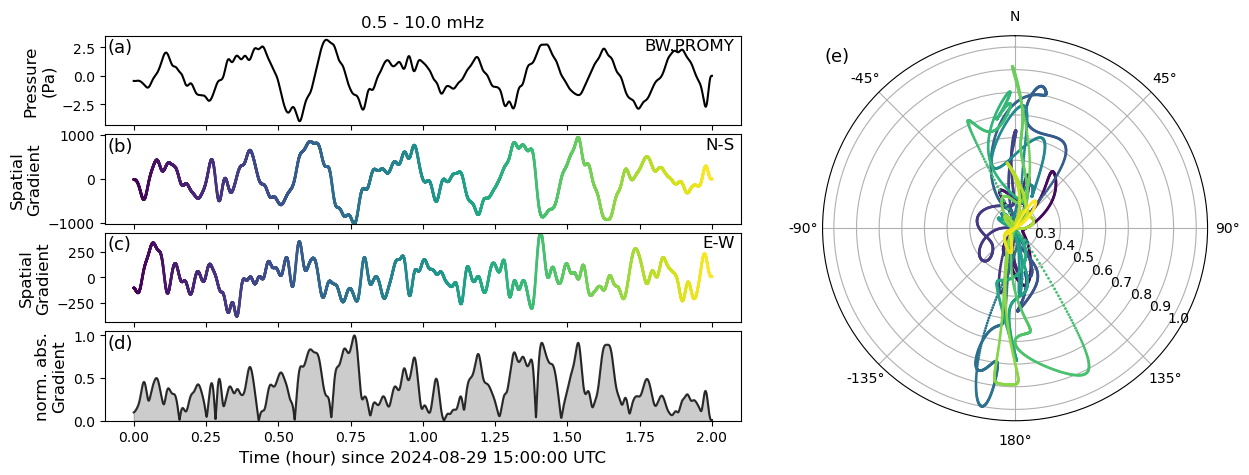

In [218]:
brmy.makeplot(plot=True)

/tmp/ipykernel_486742/2227352484.py:94: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax4.set_xticklabels(["N", "-45°", "-90°", "-135°", "180°", "135°", "90°", "45°"])


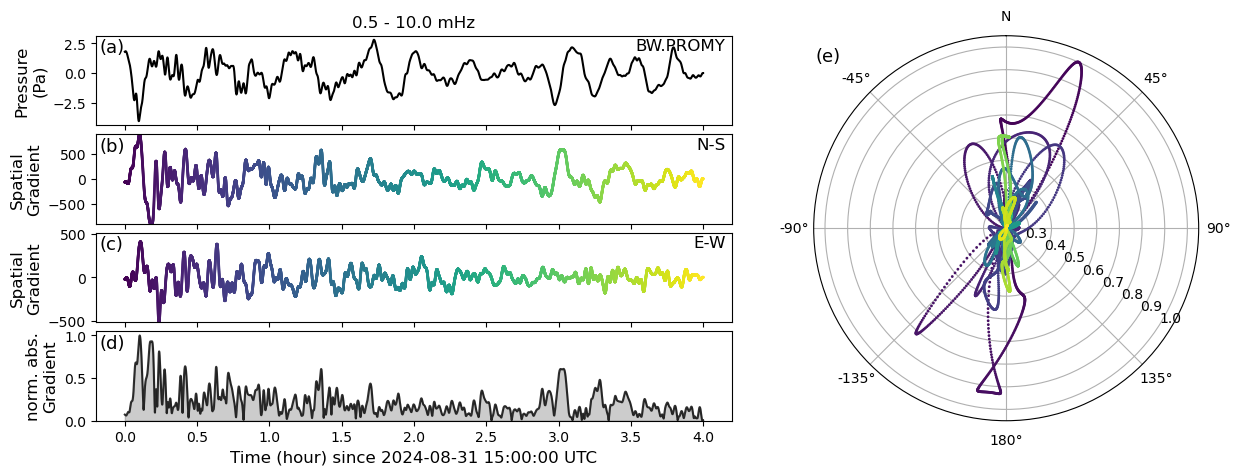

In [318]:
def __makeplot():

    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.gridspec import GridSpec

    t = brmy.gradient.select(channel="*N")[0].times()
    N = brmy.gradient.select(channel="*N")[0].data
    E = brmy.gradient.select(channel="*E")[0].data

    # pressure data
    tt = brmy.st.select(station="PROMY")[0].times()
    pp = brmy.st.select(station="PROMY")[0].data

    # normalized absolute gradient
    r = brmy_abs / max(brmy_abs)

    # specify limit for r
    rlim = 0.2

    # angle as radians
    theta = np.deg2rad(brmy_ang)

    # ___________________________________________

    tscale, tunit = 1/3600, "hour"

    gscale, gunit = 1e6, ""

    Ncol, Nrow = 9, 4

    font = 12

    lw = 1

    fig = plt.figure(figsize=(15, 5))

    gs1 = GridSpec(Nrow, Ncol, figure=fig, hspace=0.1, wspace=0.2)
    # gs2 = GridSpec(Nrow, Ncol, figure=fig, hspace=1)

    ax0 = fig.add_subplot(gs1[0, :5])
    ax1 = fig.add_subplot(gs1[1, :5])
    ax2 = fig.add_subplot(gs1[2, :5])
    ax3 = fig.add_subplot(gs1[3, :5])
    ax4 = fig.add_subplot(gs1[0:4, 5:], polar=True)

    axes = [ax0, ax1, ax2, ax3, ax4]

    # ___________________________________________

    ax0.plot(tt*tscale, pp, color="k")

    ax0.set_xticklabels([])
    ax0.set_ylabel(f"Pressure\n(Pa)", fontsize=font)
    # ax0.legend(loc=1)
    ax0.text(0.99, 0.97, brmy.reference, ha="right", va="top", transform=ax0.transAxes, fontsize=font)

    # ___________________________________________

    # ax1.plot(t*tscale, N*gscale, color=t*tscale)
    ax1.scatter(t*tscale, N*gscale, c=t*tscale, s=1, label="N-S")
    ax1.set_xticklabels([])
    ax1.set_ylim(-max(abs(N))*gscale, max(abs(N))*gscale)
    ax1.set_ylabel(f"Spatial\nGradient", fontsize=font)
    # ax1.legend(loc=1, handlelength=0, handletextpad=1)
    ax1.text(0.99, 0.97, "N-S", ha="right", va="top", transform=ax1.transAxes, fontsize=font)

    # ___________________________________________

    # ax2.plot(t*tscale, E*gscale)
    ax2.scatter(t*tscale, E*gscale, c=t*tscale, s=1, label="E-W")
    ax2.set_xticklabels([])
    ax2.set_ylim(-max(abs(E))*gscale, max(abs(E))*gscale)
    ax2.set_ylabel(f"Spatial\nGradient", fontsize=font)
    # ax2.legend(loc=1, handlelength=-1, handletextpad=0)
    ax2.text(0.99, 0.97, "E-W", ha="right", va="top", transform=ax2.transAxes, fontsize=font)

    # ___________________________________________

    ax3.plot(t*tscale, r, color='k', alpha=0.8)
    ax3.fill_between(t*tscale, r, color='k', alpha=0.2)
    ax3.set_ylim(0, 1.05)
    ax3.set_ylabel(f"norm. abs.\nGradient", fontsize=font)

    # ___________________________________________

    ax4.scatter(theta[r>rlim], r[r>rlim], c=t[r>rlim], s=1, zorder=2)
    ax4.set_theta_zero_location("N")
    ax4.set_rmin(0.2)
    ax4.set_rmax(1.05)
    ax4.set_rlabel_position(-122.5)
    ax4.grid(True)

    ax4.set_xticklabels(["N", "-45°", "-90°", "-135°", "180°", "135°", "90°", "45°"])

    ax3.set_xlabel(f"Time ({tunit}) since {config['tbeg'].date} {str(config['tbeg'].time)[:10]} UTC", fontsize=font)

    ax0.set_title(f"{config['fmin']*1e3} - {config['fmax']*1e3} mHz", fontsize=font)

    for _k, (ll, ax) in enumerate(zip(['(a)','(b)','(c)','(d)', '(e)'], axes)):
        ax.text(0.005, 0.97, ll, ha="left", va="top", transform=ax.transAxes, fontsize=font+1)

    plt.show();
    return fig

fig = __makeplot()

fig.savefig(config['path_to_figs']+f"RB_{config['tbeg'].date}_gradient.png", format="png", dpi=150, bbox_inches='tight')


In [220]:
config['tbeg'] = obspy.UTCDateTime("2024-08-31 15:00")
config['tend'] = obspy.UTCDateTime("2024-08-31 19:00")


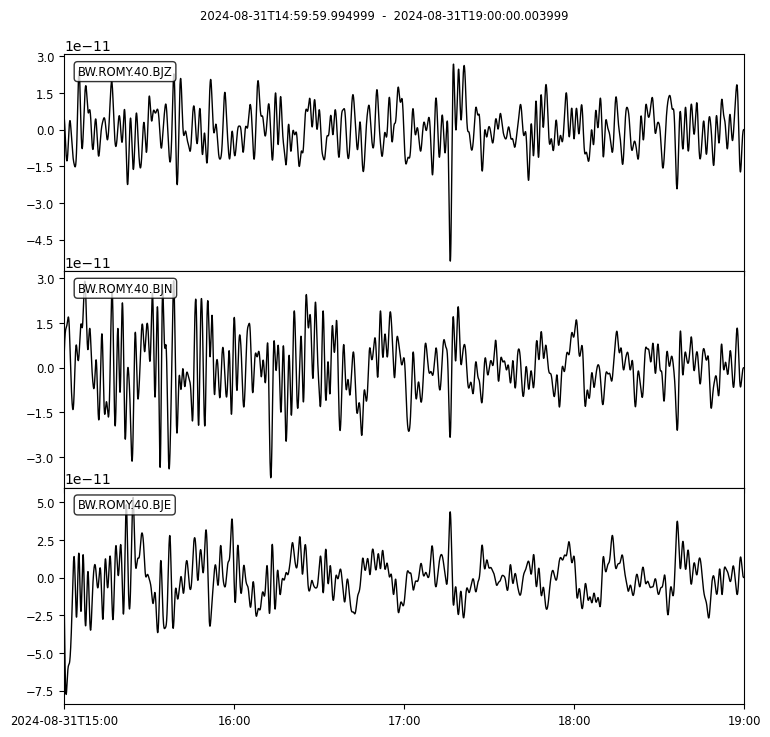

In [221]:
config['path_to_sds'] = archive_path+"temp_archive/"

config['loc'] = "40"

st0 = Stream()

st0 += __read_sds(config['path_to_sds'], f"BW.ROMY.{config['loc']}.BJZ", config['tbeg'], config['tend'])
st0 += __read_sds(config['path_to_sds'], f"BW.ROMY.{config['loc']}.BJN", config['tbeg'], config['tend'])
st0 += __read_sds(config['path_to_sds'], f"BW.ROMY.{config['loc']}.BJE", config['tbeg'], config['tend'])

st0 = st0.detrend("demean")
st0 = st0.detrend("linear")

# st0 = st0.merge(fill_value="interpolate")
# st0 = st0.merge(fill_value=np.nan)
st0 = st0.merge(fill_value=0)

st0 = st0.detrend("demean")
st0 = st0.filter("bandpass", freqmin=config['fmin'], freqmax=config['fmax'], corners=4, zerophase=True)

st0.plot(equal_scale=False);

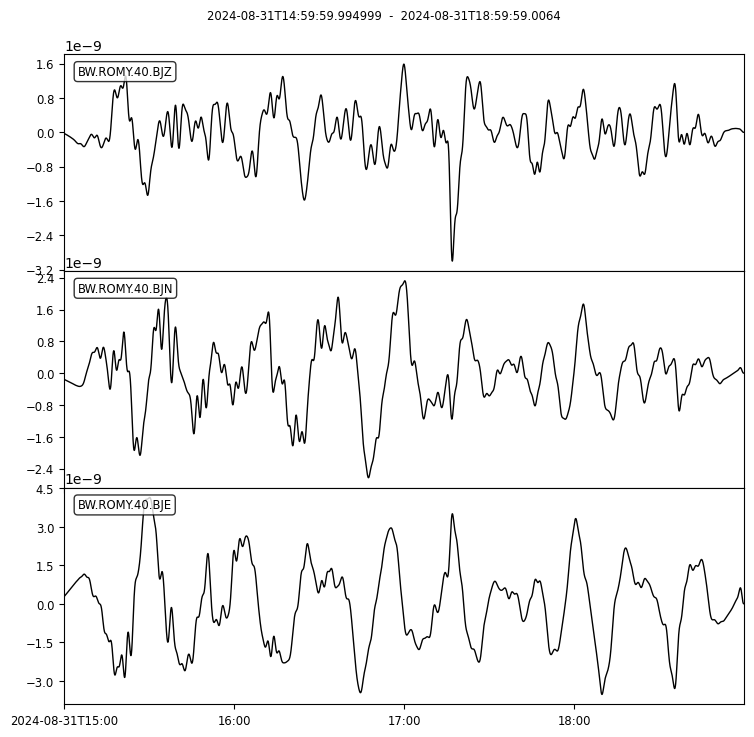

In [222]:
til1 = st0.select(station=f"ROMY", channel="*J*").copy()

til1 = til1.taper(0.05)
til1 = til1.filter("lowpass", freq=0.1, corners=4, zerophase=True)

til1 = til1.detrend("demean")
til1 = til1.detrend("simple")

til1 = til1.integrate("spline")

# equalize number of samples
npts_min = min([tr.stats.npts for tr in til1])
for tr in til1:
    if tr.stats.npts < npts_min:
        npts_min
for tr in til1:
    diff = abs(tr.stats.npts - npts_min)
    if diff != 0:
        tr.data = tr.data[:-diff]

til1 = til1.decimate(2, no_filter=True)
til1 = til1.decimate(10, no_filter=True)

til1 = til1.taper(0.1)

til1 = til1.filter("bandpass", freqmin=config['fmin'], freqmax=config['fmax'], corners=4, zerophase=True)

# for tr in til1:
#     dat = tr.data
#     for i, d in enumerate(dat):
#         if abs(d) > 1e-7:
#             dat[i] = np.nan
#     tr.data = dat
#     tr.data = __interpolate_nan(tr.data)


til1.plot(equal_scale=False);


In [223]:
from functions.get_angle import __get_angle

/tmp/ipykernel_486742/200632519.py:103: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax4.set_xticklabels(["N", "-45°", "-90°", "-135°", "180°", "135°", "90°", "45°"])


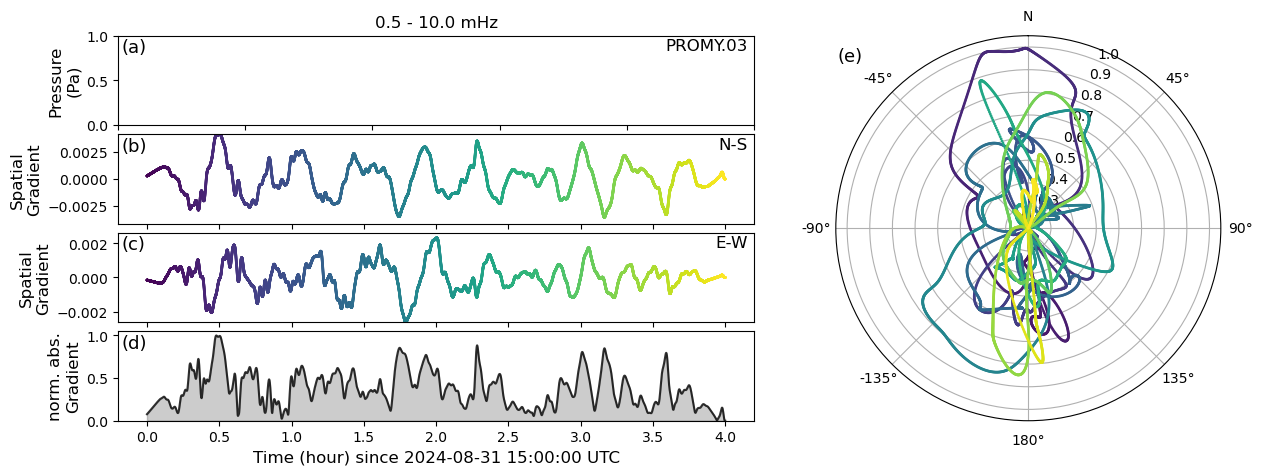

In [317]:
def __makeplot():

    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.gridspec import GridSpec

    t = til1.select(channel="*N")[0].times(reftime=config['tbeg'])

    # reverse components to match tilt definition
    E = til1.select(channel="*N")[0].data
    N = til1.select(channel="*E")[0].data

    grad_abs = np.sqrt(N**2+E**2)

    # angle of gradient (east = 0, postive anti-clockwise)
    grad_ang = __get_angle(N, E, out="deg")

    # bgrad_ang = ((bgrad_ang + 90) % 360)

    # angle relative to north
    grad_ang = ((grad_ang + 90) % 360) - 180

    # normalized absolute gradient
    r = grad_abs / max(grad_abs)

    # specify limit for r
    rlim = 0.2

    # angle as radians
    theta = np.deg2rad(grad_ang)

    # ___________________________________________

    tscale, tunit = 1/3600, "hour"

    gscale, gunit = 1e6, ""

    Ncol, Nrow = 9, 4

    font = 12

    lw = 1

    fig = plt.figure(figsize=(15, 5))

    gs1 = GridSpec(Nrow, Ncol, figure=fig, hspace=0.1, wspace=0.2)
    # gs2 = GridSpec(Nrow, Ncol, figure=fig, hspace=1)

    ax0 = fig.add_subplot(gs1[0, :5])
    ax1 = fig.add_subplot(gs1[1, :5])
    ax2 = fig.add_subplot(gs1[2, :5])
    ax3 = fig.add_subplot(gs1[3, :5])
    ax4 = fig.add_subplot(gs1[0:4, 5:], polar=True)

    axes = [ax0, ax1, ax2, ax3, ax4]
    # ___________________________________________

    # tt = np.array(df_pressure.time)
    # pp = np.array(df_pressure['BW.PROMY'])

    # ax0.plot(tt*tscale, pp, color="k", label="PROMY.03")
    ax0.set_xticklabels([])
    ax0.set_ylabel(f"Pressure\n(Pa)", fontsize=font)
    # ax0.legend(loc=1)
    ax0.text(0.99, 0.97, "PROMY.03", ha="right", va="top", transform=ax0.transAxes, fontsize=font)

    # ___________________________________________

    # ax1.plot(t*tscale, N*gscale, color=t*tscale)
    ax1.scatter(t*tscale, N*gscale, c=t*tscale, s=1, label="N-S")
    ax1.set_xticklabels([])
    ax1.set_ylim(-max(abs(N))*gscale, max(abs(N))*gscale)
    ax1.set_ylabel(f"Spatial\nGradient", fontsize=font)
    # ax1.legend(loc=1, handlelength=0, handletextpad=1)
    ax1.text(0.99, 0.97, "N-S", ha="right", va="top", transform=ax1.transAxes, fontsize=font)

    # ___________________________________________

    # ax2.plot(t*tscale, E*gscale)
    ax2.scatter(t*tscale, E*gscale, c=t*tscale, s=1, label="E-W")
    ax2.set_xticklabels([])
    ax2.set_ylim(-max(abs(E))*gscale, max(abs(E))*gscale)
    ax2.set_ylabel(f"Spatial\nGradient", fontsize=font)
    # ax2.legend(loc=1, handlelength=-1, handletextpad=0)
    ax2.text(0.99, 0.97, "E-W", ha="right", va="top", transform=ax2.transAxes, fontsize=font)

    # ___________________________________________

    ax3.plot(t*tscale, r, color='k', alpha=0.8)
    ax3.fill_between(t*tscale, r, color='k', alpha=0.2)
    ax3.set_ylim(0, 1.05)
    ax3.set_ylabel(f"norm. abs.\nGradient", fontsize=font)

    # ___________________________________________

    ax4.scatter(theta[r>rlim], r[r>rlim], c=t[r>rlim], s=1, zorder=2)
    ax4.set_theta_zero_location("N")
    ax4.set_rmin(0.2)
    ax4.set_rmax(1.05)
    ax4.set_rlabel_position(-22.5)
    ax4.grid(True)

    ax4.set_xticklabels(["N", "-45°", "-90°", "-135°", "180°", "135°", "90°", "45°"])

    ax3.set_xlabel(f"Time ({tunit}) since {config['tbeg'].date} {str(config['tbeg'].time)[:10]} UTC", fontsize=font)

    ax0.set_title(f"{config['fmin']*1e3} - {config['fmax']*1e3} mHz", fontsize=font)

    for _k, (ll, ax) in enumerate(zip(['(a)','(b)','(c)','(d)', '(e)'], axes)):
        ax.text(0.005, 0.97, ll, ha="left", va="top", transform=ax.transAxes, fontsize=font+1)

    plt.show();
    return fig

fig = __makeplot()

fig.savefig(config['path_to_figs']+f"RB_{config['tbeg'].date}_tilts.png", format="png", dpi=150, bbox_inches='tight')
